## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [4]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import torch

sys.path.insert(0, "../../../Mamoth")
sys.path.insert(0, "../../../Modules")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [7]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2022_filled.csv', encoding=enc)


In [8]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,2010-01-01,37.991999,23.654887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,37.991999,23.654887,14643.0,NaN,37.991999,23.654887,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,2010-12-16,37.950174,23.650108,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,2010-01-01,37.991999,23.654887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,37.991999,23.654887,14292.0,14056.0,37.991999,23.654887,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,2010-01-16,37.950174,23.650108,47.880348,2010-01-09,2010-01-02,2010-12-16,2010-12-16,47.880348,47.880348
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,2010-01-01,38.009965,23.825567,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,2010-01-01,38.009965,23.825567,14545.0,14253.0,38.009965,23.825567,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,2010-12-16,38.050174,23.850109,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,2010-01-01,38.009965,23.825567,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,2010-01-16,38.009965,23.825567,14141.0,14041.0,38.009965,23.825567,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,2010-01-16,38.050174,23.850109,43.371546,2010-01-09,2010-01-02,2010-12-16,2010-12-16,43.371546,43.371546
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,2010-01-01,37.933609,23.731244,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,2010-01-01,37.933609,23.731244,14622.0,14349.0,37.933609,23.731244,14397.75,13992.857143,14356.300000,14154.3,14739.285714,14257.875000,14892.000000,14366.523810,2010-12-16,37.950174,23.750109,0.000000,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.000000,0.000000


In [9]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [10]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [11]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.0,NaN,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000
1,αγιας βαρβαρας,αττικης,23.65697,37.99220,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14292.0,14056.0,14381.60,14082.700000,14386.500000,14086.1,14667.083333,14232.117647,14975.076923,14330.263158,47.880348,47.880348,47.880348
2,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-01,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.0,14253.0,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000
3,αγιας παρασκευης,αττικης,23.82642,38.00806,2010-01-16,2010,1,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14141.0,14041.0,14302.00,14045.200000,14416.727273,14017.0,14632.133333,14182.944444,14865.133333,14297.125000,43.371546,43.371546,43.371546
4,αγιου δημητριου,αττικης,23.73031,37.93357,2010-01-01,2010,1,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.0,14349.0,14397.75,13992.857143,14356.300000,14154.3,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000


In [12]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2010-01-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14643.000000,NaN,14381.600000,14082.700000,14386.500000,14086.100000,14667.083333,14232.117647,14975.076923,14330.263158,0.000000,0.000000,0.000000
1,2010-01-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2010.0,1.0,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14545.000000,14253.000000,14302.000000,14045.200000,14416.727273,14017.000000,14632.133333,14182.944444,14865.133333,14297.125000,0.000000,0.000000,0.000000
2,2010-01-01,αγιου δημητριου,αττικης,23.730310,37.933570,2010.0,1.0,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,14622.000000,14349.000000,14397.750000,13992.857143,14356.300000,14154.300000,14739.285714,14257.875000,14892.000000,14366.523810,0.000000,0.000000,0.000000
3,2010-01-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2010.0,1.0,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,14600.000000,14269.000000,14258.000000,14025.454545,14415.100000,14055.666667,14752.700000,14193.833333,14965.200000,14303.500000,0.000000,0.000000,0.000000
4,2010-01-01,αγκιστριου,αττικης,23.340090,37.695030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14682.000000,14463.000000,14338.250000,14184.555556,14295.500000,14133.363636,14494.600000,14217.933333,14572.166667,14342.210526,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20587,2022-12-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2022.0,12.0,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,14388.000000,14246.000000,14126.733333,13924.937500,14387.636364,13976.357143,14458.777778,13907.812500,14918.823529,14314.857143,878.533587,64.381842,66.835793
20588,2022-12-16,φυλης,αττικης,23.672940,38.105580,2022.0,12.0,0.229914,0.080065,-0.175694,-0.080065,0.209037,0.092639,-0.151707,-0.092639,0.054137,0.051285,0.043086,0.051285,14322.250000,14038.500000,14073.461134,13844.457617,14293.844551,13879.225000,14291.370629,13776.013792,14853.395887,14204.923958,832.134717,42.456445,44.312617
20589,2022-12-16,χαλανδριου,αττικης,23.809410,38.022260,2022.0,12.0,0.200400,0.148692,-0.184211,-0.148692,0.218178,0.148194,-0.194554,-0.148194,0.045676,0.032925,0.029887,0.032925,14403.000000,14164.000000,14091.900000,13949.066667,14388.250000,13990.642857,14367.100000,13856.142857,14917.647059,14351.625000,930.487912,72.550454,75.314096
20590,2022-12-16,χαϊδαριου,αττικης,23.630840,38.009420,2022.0,12.0,0.320253,0.268085,-0.157603,-0.268085,0.343233,0.240475,-0.205532,-0.240475,0.048015,0.063077,0.058487,0.063077,14339.000000,14122.000000,14190.052632,13901.263158,14320.923077,13998.000000,14417.083333,13866.933333,14846.409091,14306.055556,839.945864,58.605859,61.133574


In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [14]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [15]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [16]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [17]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [18]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [19]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [20]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

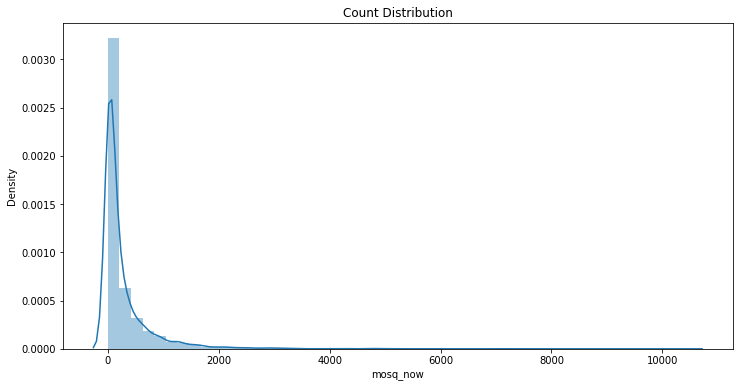

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [22]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

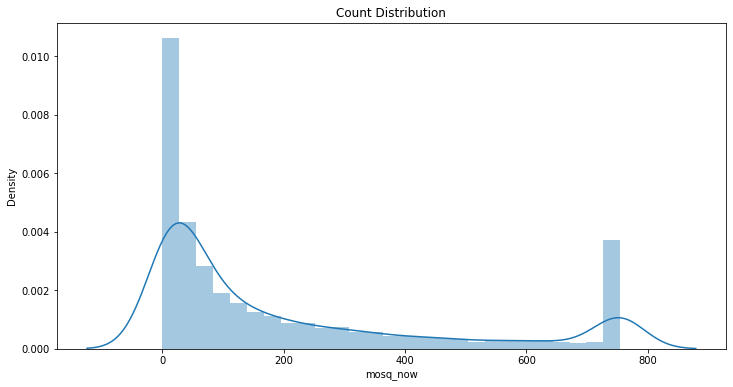

In [23]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

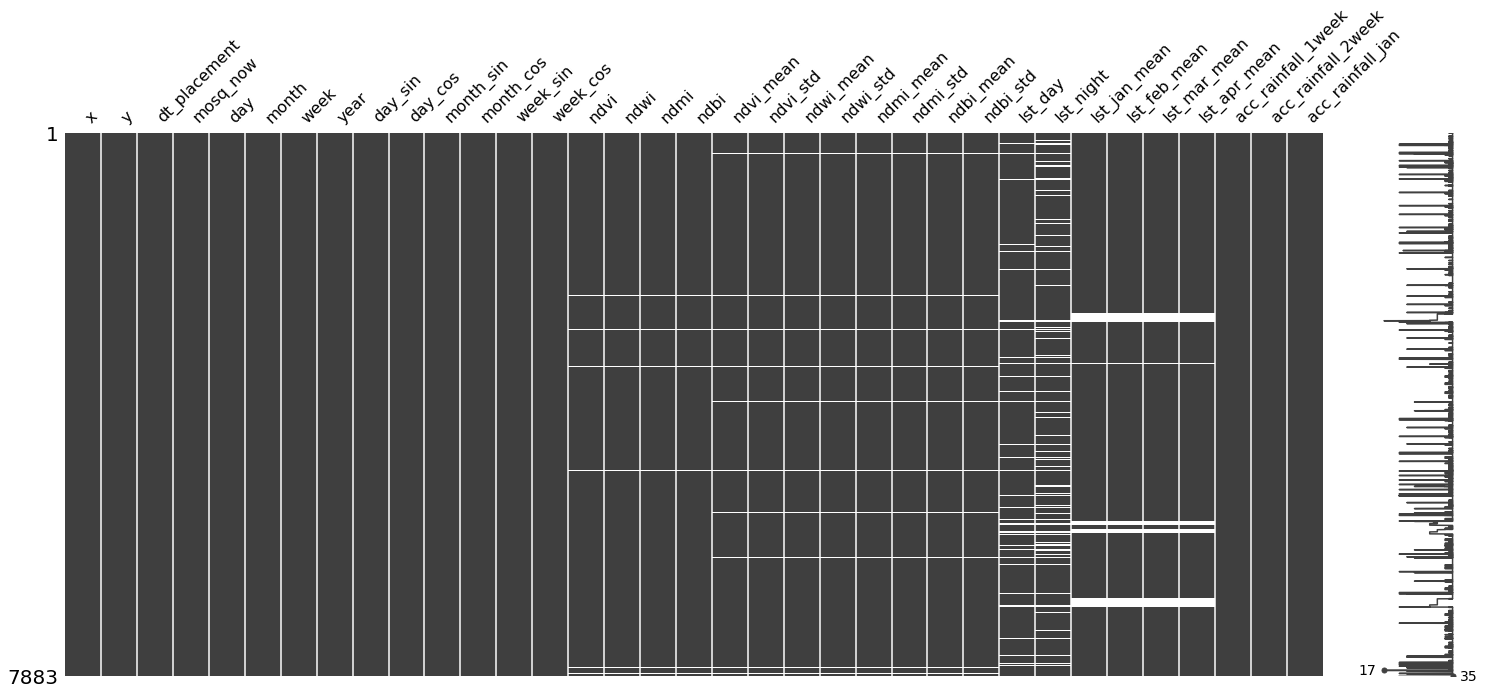

In [24]:
missingno.matrix(mosquito_data_nuts2)

In [25]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [26]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

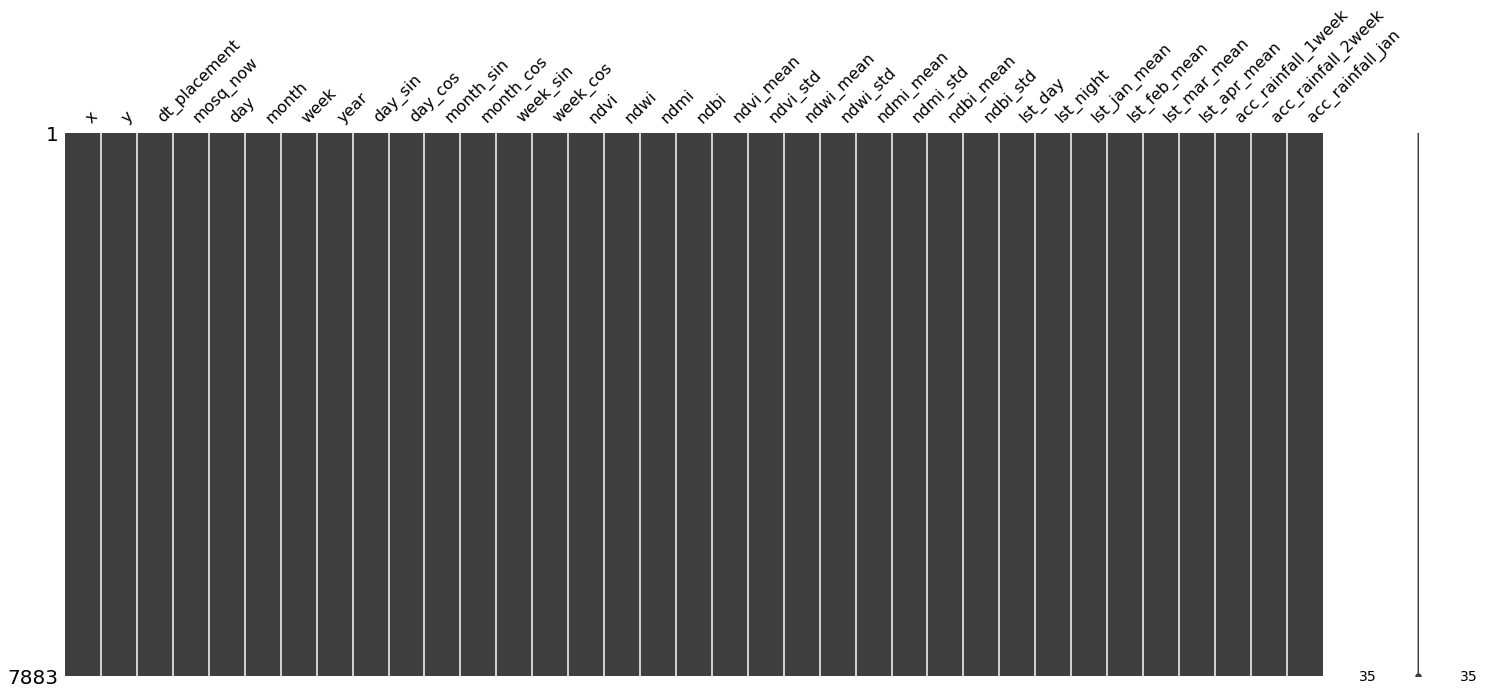

In [27]:
missingno.matrix(mosquito_data_nuts2)

In [28]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [29]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [30]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.25, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 20.41327 | Val Loss: 24.22933 | Train Acc: 2.837| Val Acc: 2.004
Epoch 002: | Train Loss: 18.96907 | Val Loss: 25.23001 | Train Acc: 2.275| Val Acc: 2.009
Epoch 003: | Train Loss: 18.54248 | Val Loss: 25.38490 | Train Acc: 2.212| Val Acc: 2.064
Epoch 004: | Train Loss: 18.16099 | Val Loss: 25.43103 | Train Acc: 2.154| Val Acc: 2.046
Epoch 005: | Train Loss: 18.04052 | Val Loss: 23.90808 | Train Acc: 2.142| Val Acc: 1.952
Epoch 006: | Train Loss: 17.74739 | Val Loss: 23.63312 | Train Acc: 2.103| Val Acc: 1.937
Epoch 007: | Train Loss: 17.55014 | Val Loss: 23.66739 | Train Acc: 2.061| Val Acc: 1.907
Epoch 008: | Train Loss: 17.58716 | Val Loss: 23.58482 | Train Acc: 2.065| Val Acc: 1.925
Epoch 009: | Train Loss: 17.48645 | Val Loss: 23.28106 | Train Acc: 2.043| Val Acc: 1.930
Epoch 010: | Train Loss: 17.23644 | Val Loss: 23.55704 | Train Acc: 2.033| Val Acc: 1.936
Epoch 011: | Train Loss: 17.06930 | Val Loss: 23.54758 | Train Acc: 2.046| Val Acc: 1.957
Epoch 012:

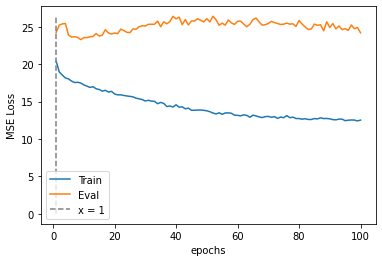

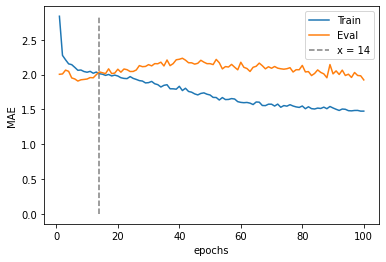

In [31]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 100, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [32]:
metrics(train, test, threshold=30)

MAE on train set:  157.1283195467334
min prediction: 1
max prediction: 1122

MAE on test set:  147.96925392434036
Error ⩽ 30: 19.68 %
min prediction: 1
max prediction: 1025


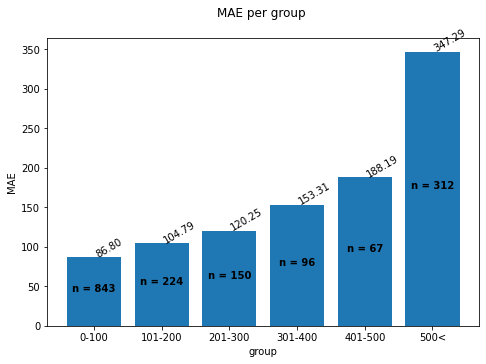

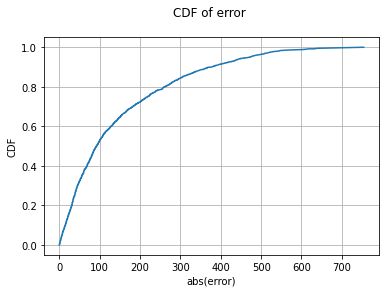

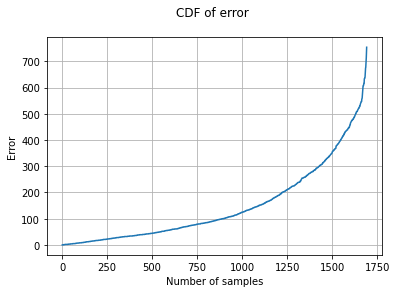

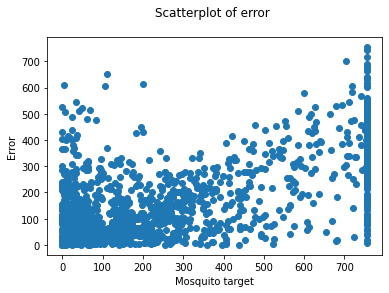

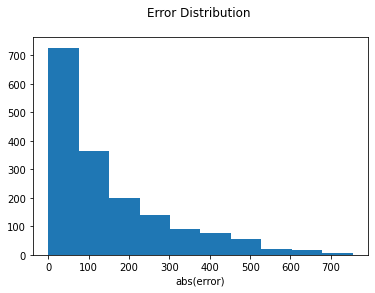

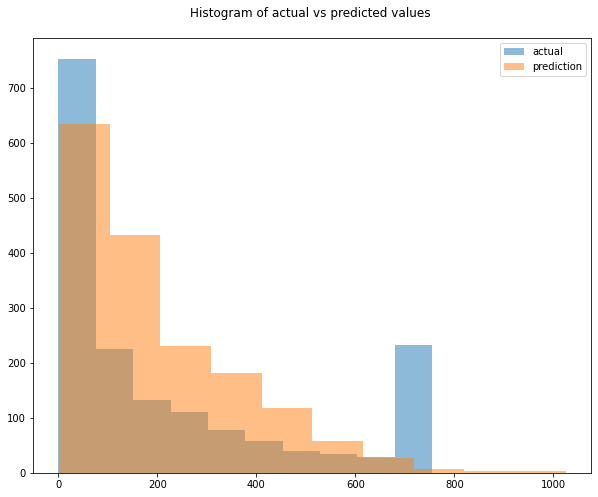

In [33]:
validation_plots(test,model_type)

In [34]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.25, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 19.33399 | Val Loss: 9.40802 | Train Acc: 2.548| Val Acc: 2.633
Epoch 002: | Train Loss: 17.87089 | Val Loss: 8.22793 | Train Acc: 2.142| Val Acc: 2.633
Epoch 003: | Train Loss: 17.94093 | Val Loss: 8.69532 | Train Acc: 2.142| Val Acc: 2.633
Epoch 004: | Train Loss: 17.55933 | Val Loss: 14.49969 | Train Acc: 2.098| Val Acc: 3.633
Epoch 005: | Train Loss: 17.65713 | Val Loss: 11.39151 | Train Acc: 2.092| Val Acc: 3.633
Epoch 006: | Train Loss: 17.35568 | Val Loss: 13.66525 | Train Acc: 2.032| Val Acc: 3.633
Epoch 007: | Train Loss: 17.33474 | Val Loss: 11.94397 | Train Acc: 2.024| Val Acc: 3.633
Epoch 008: | Train Loss: 17.07384 | Val Loss: 12.83915 | Train Acc: 1.986| Val Acc: 3.633
Epoch 009: | Train Loss: 17.15523 | Val Loss: 13.02609 | Train Acc: 2.024| Val Acc: 3.633
Epoch 010: | Train Loss: 16.91603 | Val Loss: 13.34984 | Train Acc: 1.979| Val Acc: 3.633
Epoch 011: | Train Loss: 16.90792 | Val Loss: 12.95814 | Train Acc: 1.994| Val Acc: 3.633
Epoch 012: | 

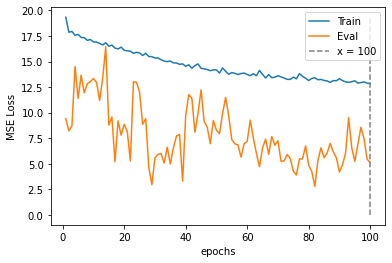

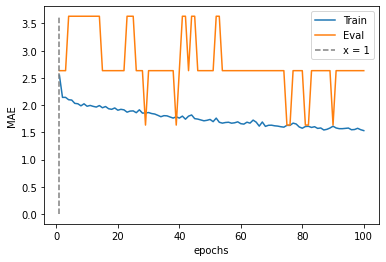

In [35]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 100, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [36]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [37]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [38]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [39]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [40]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [41]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

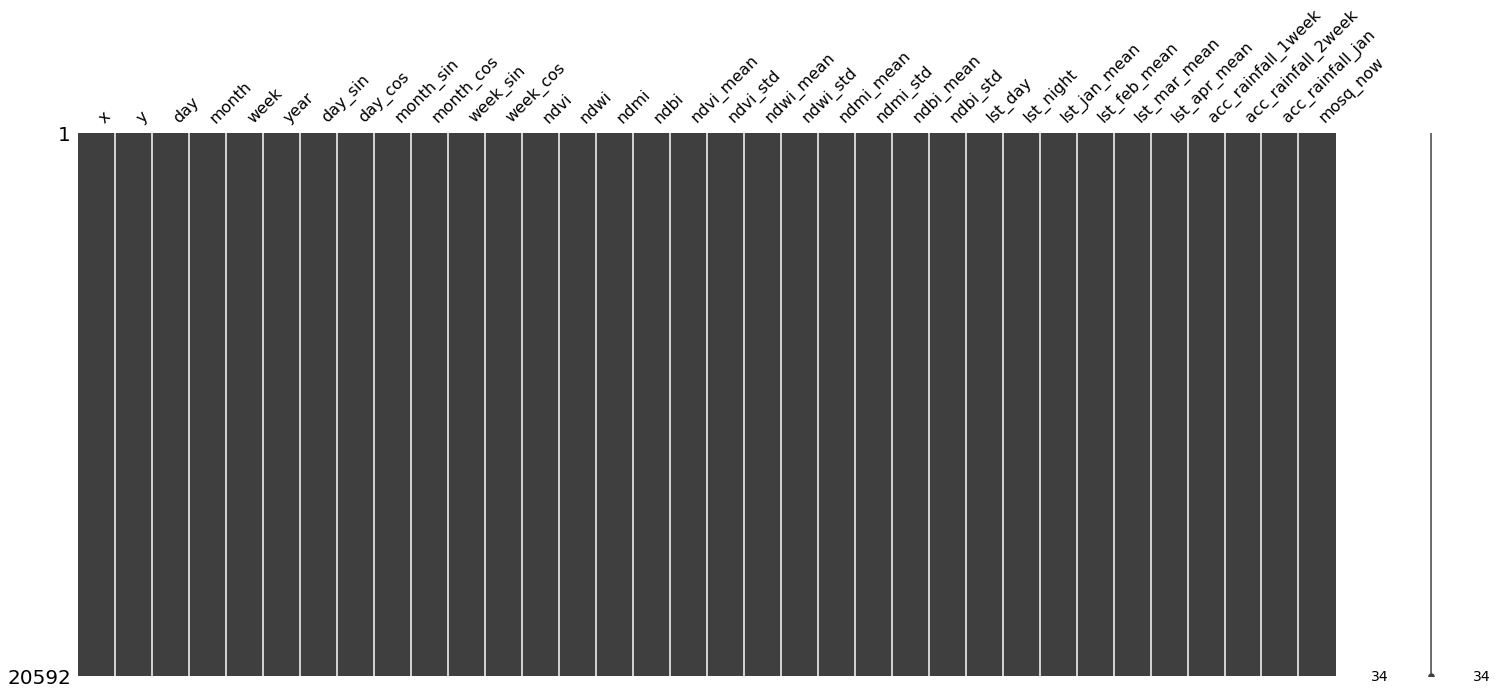

In [42]:
missingno.matrix(dataset_mamoth)

In [43]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [44]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [45]:
predictions = give_predictions(model, dataset_mamoth)

In [46]:
mosqutio_predictions['mosq_pred'] = predictions

In [47]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2010-01-01,150
1,23.826420,38.008060,2010-01-01,327
2,23.730310,37.933570,2010-01-01,319
3,23.713410,38.047210,2010-01-01,295
4,23.340090,37.695030,2010-01-01,177
...,...,...,...,...
20587,23.776280,38.014770,2022-12-16,128
20588,23.672940,38.105580,2022-12-16,195
20589,23.809410,38.022260,2022-12-16,122
20590,23.630840,38.009420,2022-12-16,68


In [48]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2022.csv', index = False)

In [49]:
torch.save(model.state_dict(), f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_Model_2010-2022.pt')

In [50]:
import pickle

In [51]:
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer_2010-2022.pkl', 'wb'))